# Análisis de la retención de usuarios a lo largo del tiempo.

### Objetivo:

- Analizar cuántos usuarios abandonan la plataforma (churn).
- Analizar cuánto tiempo permanecen activos antes de abandonar.
- Comparar la tasa de churn entre distintos planes.
- Analizar la evolución de la retención de las diferentes cohortes de usuarios.

Este análisis nos ayudará a entender el abandono, la permanencia y la retención de los usuarios a lo largo del tiempo.

In [127]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
plt.style.use("default")


### Carga de datos de usuarios y sesiones.


In [128]:
users = pd.read_csv("../data/raw/users.csv")
sessions = pd.read_csv("../data/raw/sessions.csv")

### Revisión de la información básica del dataset de usuarios.


In [129]:
users.head()

,user_id,signup_date,country,acquisition_channel,utm_campaign,first_device,gender,age,plan,marketing_opt_in,is_churned,churn_date
0,1,2024-03-04,AR,affiliate,NaN,mobile,male,23,free,False,False,NaN
1,2,2025-07-07,US,organic,retargeting,desktop,male,27,basic,True,False,NaN
2,3,2025-04-13,FR,organic,spring_sale,mobile,female,38,basic,True,False,NaN
3,4,2024-11-09,US,organic,NaN,mobile,female,33,enterprise,True,False,NaN
4,5,2024-11-05,ES,affiliate,brand,desktop,unknown,28,free,NaN,True,2025-02-21


### Preparación de fechas para el análisis de retención.


In [130]:
users["signup_date"] = pd.to_datetime(users["signup_date"])
users["churn_date"] = pd.to_datetime(users["churn_date"])


### Análisis de abandono de usuarios (churn).

Calculamos cuántos usuarios han abandonado la plataforma y cuántos permanecen activos.


In [131]:
churn_counts = users["is_churned"].value_counts()
churn_counts


is_churned
False    31139
True     18861
Name: count, dtype: int64

### Distribución de usuarios según su estado de churn.

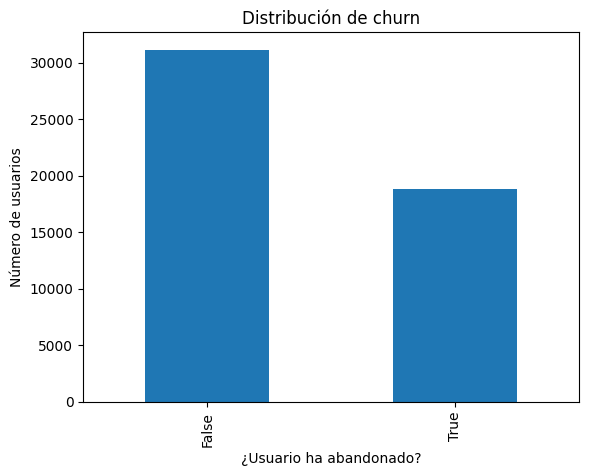

In [132]:
churn_counts.plot(kind="bar")
plt.title("Distribución de churn")
plt.xlabel("¿Usuario ha abandonado?")
plt.ylabel("Número de usuarios")
plt.show()


### Análisis del tiempo de permanencia de los usuarios.

Calculamos los días transcurridos entre el registro y el abandono para los usuarios que han dejado la plataforma.


In [133]:
users["lifetime_days"] = (
    users["churn_date"] - users["signup_date"]
).dt.days
users["lifetime_days"].describe()


count    18861.000000
mean        99.806479
std         96.128163
min          0.000000
25%         29.000000
50%         70.000000
75%        140.000000
max        699.000000
Name: lifetime_days, dtype: float64

### Distribución del tiempo de permanencia antes del abandono.


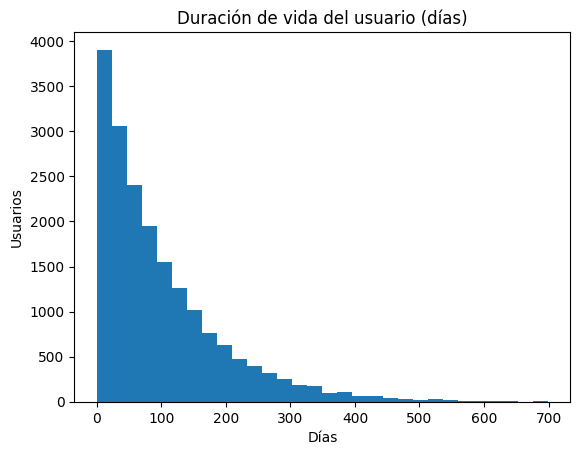

In [134]:
users["lifetime_days"].dropna().plot(kind="hist", bins=30)
plt.title("Duración de vida del usuario (días)")
plt.xlabel("Días")
plt.ylabel("Usuarios")
plt.show()


### Comparación del churn según el plan contratado.

Analizamos si la tasa de abandono varía entre los distintos planes.


In [135]:
churn_by_plan = users.groupby("plan")["is_churned"].mean()
churn_by_plan


plan
basic         0.301828
enterprise    0.094433
free          0.473733
pro           0.195129
Name: is_churned, dtype: float64

### Tasa de churn por tipo de plan.


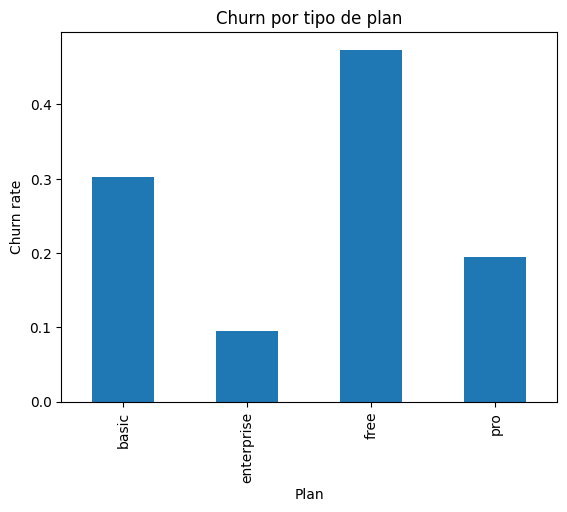

In [136]:
churn_by_plan.plot(kind="bar")
plt.title("Churn por tipo de plan")
plt.xlabel("Plan")
plt.ylabel("Churn rate")
plt.show()


### Análisis de retención por cohortes.

Agrupamos a los usuarios según el periodo en el que se registraron para analizar cómo evoluciona su retención a lo largo del tiempo.

Este análisis permite comparar el comportamiento de diferentes grupos de usuarios y detectar posibles cambios en la retención de la plataforma.

In [137]:
users["signup_month"] = users["signup_date"].dt.to_period("M")

users[["user_id", "signup_date", "signup_month"]].head()


,user_id,signup_date,signup_month
0,1,2024-03-04,2024-03
1,2,2025-07-07,2025-07
2,3,2025-04-13,2025-04
3,4,2024-11-09,2024-11
4,5,2024-11-05,2024-11


### Número de usuarios por cohorte.

Contamos cuántos usuarios forman parte de cada cohorte para conocer el tamaño de los grupos que posteriormente analizaremos.

In [138]:
users.groupby("signup_month")["user_id"].nunique()

signup_month
2024-01    2217
2024-02    2006
2024-03    2151
2024-04    2129
2024-05    2157
2024-06    2133
2024-07    2173
2024-08    2187
2024-09    2052
2024-10    2139
2024-11    2063
2024-12    2208
2025-01    2176
2025-02    1890
2025-03    2210
2025-04    2129
2025-05    2189
2025-06    2106
2025-07    2199
2025-08    2150
2025-09    2037
2025-10    2126
2025-11    2074
2025-12    1099
Freq: M, Name: user_id, dtype: int64

### Preparación de las fechas de actividad.

Convertimos la fecha de inicio de las sesiones a formato fecha para poder comparar el momento de actividad con la fecha de registro de cada usuario.

In [139]:
sessions["session_start"] = pd.to_datetime(sessions["session_start"])

#### Unión de sesión con la información del usuario incluyendo su cohorte.

In [140]:
sessions_cohort = sessions.merge(
    users[["user_id", "signup_month"]],
    on="user_id",
    how="left"
)

sessions_cohort.head()

,session_id,user_id,session_start,duration_sec,pages_viewed,device,traffic_source,primary_action,signup_month
0,1,30602,2024-04-04 13:53:00,103.0,5.0,desktop,paid_search,add_to_cart,2024-03
1,2,9439,2024-10-07 00:37:00,379.0,4.0,desktop,organic,add_to_cart,2024-09
2,3,23658,2024-10-18 13:33:00,222.0,3.0,mobile,paid_social,checkout,2024-06
3,4,3423,2025-04-15 16:53:00,246.0,7.0,mobile,referral,search,2025-03
4,5,24425,2024-04-11 03:35:00,924.0,4.0,mobile,organic,add_to_cart,2024-02


#### Mes por sesion.

In [141]:
sessions_cohort["session_month"] = (
    sessions_cohort["session_start"].dt.to_period("M")
)

sessions_cohort.head()

,session_id,user_id,session_start,duration_sec,pages_viewed,device,traffic_source,primary_action,signup_month,session_month
0,1,30602,2024-04-04 13:53:00,103.0,5.0,desktop,paid_search,add_to_cart,2024-03,2024-04
1,2,9439,2024-10-07 00:37:00,379.0,4.0,desktop,organic,add_to_cart,2024-09,2024-10
2,3,23658,2024-10-18 13:33:00,222.0,3.0,mobile,paid_social,checkout,2024-06,2024-10
3,4,3423,2025-04-15 16:53:00,246.0,7.0,mobile,referral,search,2025-03,2025-04
4,5,24425,2024-04-11 03:35:00,924.0,4.0,mobile,organic,add_to_cart,2024-02,2024-04


#### Diferencia de meses entre registro y sesión

In [142]:
sessions_cohort["months_since_signup"] = (
    sessions_cohort["session_month"] - sessions_cohort["signup_month"]
).apply(lambda x: x.n)

sessions_cohort.head()

,session_id,user_id,session_start,duration_sec,pages_viewed,device,traffic_source,primary_action,signup_month,session_month,months_since_signup
0,1,30602,2024-04-04 13:53:00,103.0,5.0,desktop,paid_search,add_to_cart,2024-03,2024-04,1
1,2,9439,2024-10-07 00:37:00,379.0,4.0,desktop,organic,add_to_cart,2024-09,2024-10,1
2,3,23658,2024-10-18 13:33:00,222.0,3.0,mobile,paid_social,checkout,2024-06,2024-10,4
3,4,3423,2025-04-15 16:53:00,246.0,7.0,mobile,referral,search,2025-03,2025-04,1
4,5,24425,2024-04-11 03:35:00,924.0,4.0,mobile,organic,add_to_cart,2024-02,2024-04,2


#### Agrupación por cohorte y por mes desde el registro.

In [143]:
cohort_activity = (
    sessions_cohort
    .groupby(["signup_month", "months_since_signup"])["user_id"]
    .nunique()
    .reset_index()
)

cohort_activity.head(10)

,signup_month,months_since_signup,user_id
0,2024-01,0,122
1,2024-01,1,146
2,2024-01,2,96
3,2024-01,3,58
4,2024-01,4,38
5,2024-01,5,25
6,2024-01,6,20
7,2024-01,7,9
8,2024-01,8,8
9,2024-01,9,8


In [144]:
cohort_table = cohort_activity.pivot(
    index="signup_month",
    columns="months_since_signup",
    values="user_id"
)

cohort_table

months_since_signup,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,21,23
signup_month,,,,,,,,,,,,,,,,,,,,,,
2024-01,122.0,146.0,96.0,58.0,38.0,25.0,20.0,9.0,8.0,8.0,8.0,5.0,4.0,5.0,2.0,1.0,1.0,1.0,1.0,NaN,NaN,1.0
2024-02,113.0,129.0,97.0,61.0,39.0,31.0,27.0,13.0,13.0,8.0,2.0,2.0,2.0,2.0,2.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN
2024-03,96.0,152.0,102.0,69.0,54.0,30.0,23.0,16.0,16.0,11.0,6.0,2.0,3.0,4.0,2.0,2.0,NaN,1.0,1.0,2.0,1.0,NaN
2024-04,104.0,130.0,79.0,57.0,37.0,29.0,11.0,9.0,6.0,7.0,3.0,7.0,2.0,1.0,1.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN
2024-05,119.0,146.0,96.0,77.0,46.0,31.0,18.0,13.0,13.0,11.0,10.0,6.0,3.0,3.0,2.0,1.0,2.0,2.0,NaN,NaN,NaN,NaN
2024-06,104.0,148.0,76.0,65.0,35.0,33.0,14.0,12.0,6.0,9.0,NaN,2.0,3.0,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
2024-07,106.0,138.0,90.0,76.0,52.0,43.0,31.0,12.0,13.0,7.0,5.0,6.0,5.0,2.0,1.0,1.0,NaN,3.0,NaN,NaN,NaN,NaN
2024-08,101.0,159.0,95.0,65.0,49.0,35.0,22.0,16.0,13.0,9.0,7.0,5.0,2.0,4.0,1.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN
2024-09,93.0,136.0,87.0,62.0,43.0,29.0,17.0,9.0,7.0,2.0,2.0,NaN,1.0,2.0,3.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN


In [145]:
cohort_sizes = users.groupby("signup_month")["user_id"].nunique()

cohort_retention = (
    cohort_table
    .divide(cohort_sizes, axis=0)
    .mul(100)
    .round(1)
)

cohort_retention

months_since_signup,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,21,23
signup_month,,,,,,,,,,,,,,,,,,,,,,
2024-01,5.5,6.6,4.3,2.6,1.7,1.1,0.9,0.4,0.4,0.4,0.4,0.2,0.2,0.2,0.1,0.0,0.0,0.0,0.0,NaN,NaN,0.0
2024-02,5.6,6.4,4.8,3.0,1.9,1.5,1.3,0.6,0.6,0.4,0.1,0.1,0.1,0.1,0.1,NaN,NaN,0.0,NaN,NaN,NaN,NaN
2024-03,4.5,7.1,4.7,3.2,2.5,1.4,1.1,0.7,0.7,0.5,0.3,0.1,0.1,0.2,0.1,0.1,NaN,0.0,0.0,0.1,0.0,NaN
2024-04,4.9,6.1,3.7,2.7,1.7,1.4,0.5,0.4,0.3,0.3,0.1,0.3,0.1,0.0,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN
2024-05,5.5,6.8,4.5,3.6,2.1,1.4,0.8,0.6,0.6,0.5,0.5,0.3,0.1,0.1,0.1,0.0,0.1,0.1,NaN,NaN,NaN,NaN
2024-06,4.9,6.9,3.6,3.0,1.6,1.5,0.7,0.6,0.3,0.4,NaN,0.1,0.1,0.1,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2024-07,4.9,6.4,4.1,3.5,2.4,2.0,1.4,0.6,0.6,0.3,0.2,0.3,0.2,0.1,0.0,0.0,NaN,0.1,NaN,NaN,NaN,NaN
2024-08,4.6,7.3,4.3,3.0,2.2,1.6,1.0,0.7,0.6,0.4,0.3,0.2,0.1,0.2,0.0,0.0,0.1,NaN,NaN,NaN,NaN,NaN
2024-09,4.5,6.6,4.2,3.0,2.1,1.4,0.8,0.4,0.3,0.1,0.1,NaN,0.0,0.1,0.1,0.0,NaN,NaN,NaN,NaN,NaN,NaN


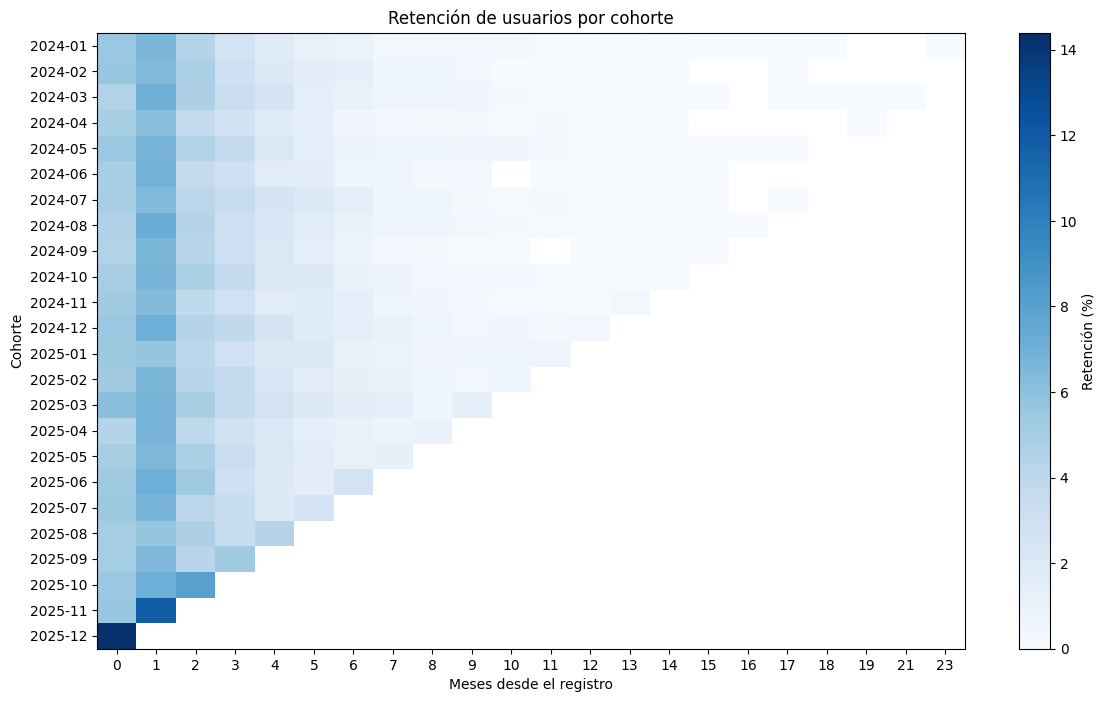

In [146]:
plt.figure(figsize=(14, 8))

plt.imshow(
    cohort_retention,
    aspect="auto",
    cmap="Blues"
)

plt.colorbar(label="Retención (%)")

plt.xticks(
    range(len(cohort_retention.columns)),
    cohort_retention.columns
)

plt.yticks(
    range(len(cohort_retention.index)),
    cohort_retention.index
)

plt.title("Retención de usuarios por cohorte")
plt.xlabel("Meses desde el registro")
plt.ylabel("Cohorte")

plt.show()

### Interpretación

El análisis de cohortes permite observar cómo evoluciona la retención de los usuarios a lo largo de los meses desde su registro.

Cada fila representa una cohorte de usuarios según su mes de registro, mientras que las columnas indican los meses transcurridos desde el registro.

La retención disminuye de forma progresiva a medida que aumenta el tiempo desde el registro, mostrando una pérdida significativa de usuarios durante los primeros meses.

---

### Observaciones

* La retención es más alta durante los primeros meses después del registro.
* Se produce una caída progresiva de la actividad conforme aumenta el tiempo desde el registro.
* Las cohortes presentan comportamientos similares, aunque existen diferencias en sus niveles de retención.
* Las cohortes más recientes tienen menos meses disponibles para analizar, por lo que no deben compararse directamente con las cohortes más antiguas en períodos que todavía no han transcurrido.
